In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('Advertising.csv', index_col=0)
data.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
data.shape

(200, 4)

In [4]:
data.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


<Axes: xlabel='Newspaper'>

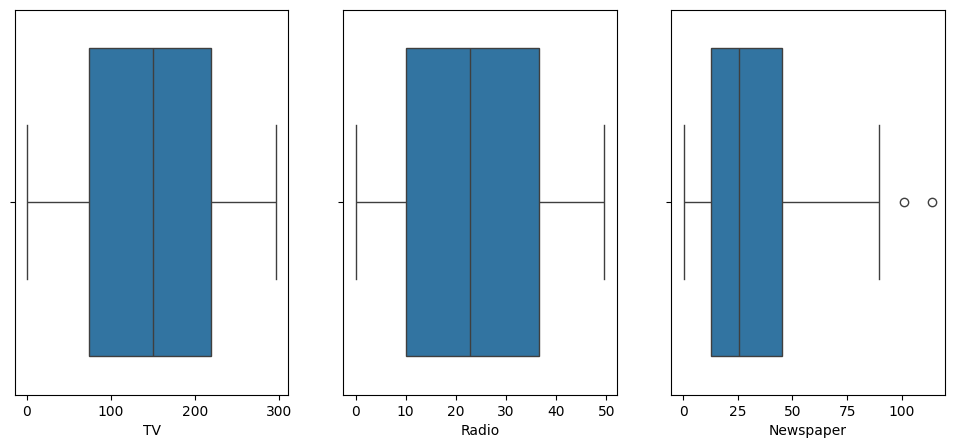

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
sns.boxplot(data=data, x='TV')
plt.subplot(1,3,2)
sns.boxplot(data=data, x='Radio')
plt.subplot(1,3,3)
sns.boxplot(data=data, x='Newspaper')

<Axes: xlabel='Sales'>

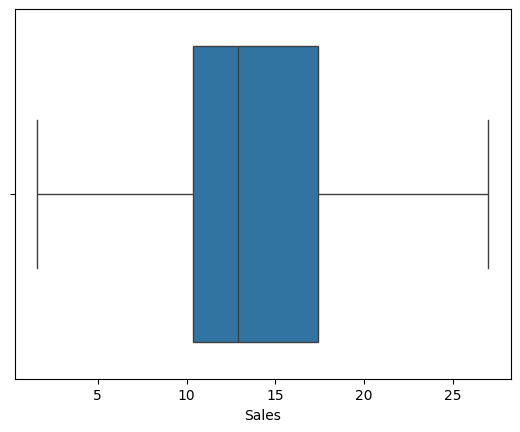

In [9]:
sns.boxplot(data=data, x='Sales')

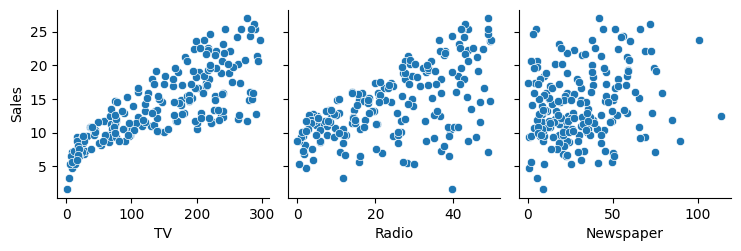

In [10]:
sns.pairplot(data, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales')

<Axes: >

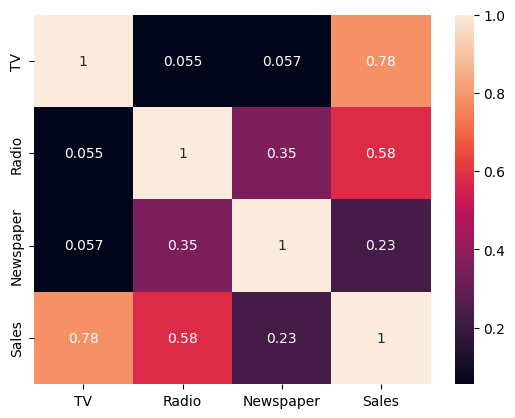

In [11]:
sns.heatmap(data.corr(), annot=True, )

# Model Building

In [12]:
import statsmodels.api as sm

In [13]:
X = data['TV']
y = data['Sales']

In [15]:
X.head()

1    230.1
2     44.5
3     17.2
4    151.5
5    180.8
Name: TV, dtype: float64

In [16]:
y.head()

1    22.1
2    10.4
3     9.3
4    18.5
5    12.9
Name: Sales, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Constant term added explicitly since statsmodels does not include an intercept by default.

In [23]:
X_train_sm = sm.add_constant(X_train)
X_train_sm

,const,TV
80,1.0,116.0
198,1.0,177.0
39,1.0,43.1
25,1.0,62.3
123,1.0,224.0
...,...,...
107,1.0,25.0
15,1.0,204.1
93,1.0,217.7
180,1.0,165.6


OLS model fitted on training data using least squares estimation.

In [32]:
lr = sm.OLS(y_train, X_train_sm).fit()

In [33]:
lr.params

const    7.119638
TV       0.046530
dtype: float64

Coefficient values indicate a positive linear relationship between TV advertising and sales.

In [34]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     228.5
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           1.68e-32
Time:                        10:43:18   Log-Likelihood:                -415.93
No. Observations:                 160   AIC:                             835.9
Df Residuals:                     158   BIC:                             842.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1196      0.530     13.446      0.0

In [53]:
y_train_pred = lr.predict(X_train_sm)

In [54]:
y_train_pred

80     12.517088
198    15.355401
39      9.125070
25     10.018441
123    17.542299
         ...    
107     8.282882
15     16.616357
93     17.249161
180    14.824962
103    20.157270
Length: 160, dtype: float64

In [55]:
res = (y_train - y_train_pred)

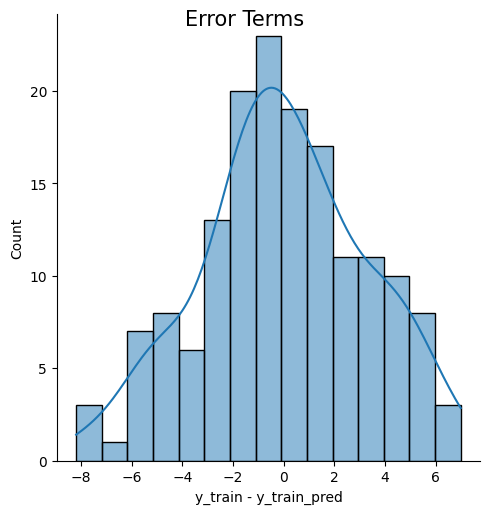

In [56]:
sns.displot(res, bins=15, kde=True)
plt.suptitle('Error Terms', fontsize=15)
plt.xlabel('y_train - y_train_pred')
plt.show()

Residual distribution plotted to check normality assumption.

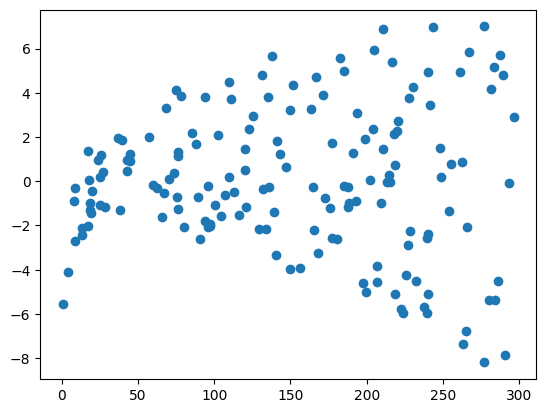

In [58]:
plt.scatter(X_train,res)
plt.show()

In [67]:
X_test_sm = sm.add_constant(X_test)

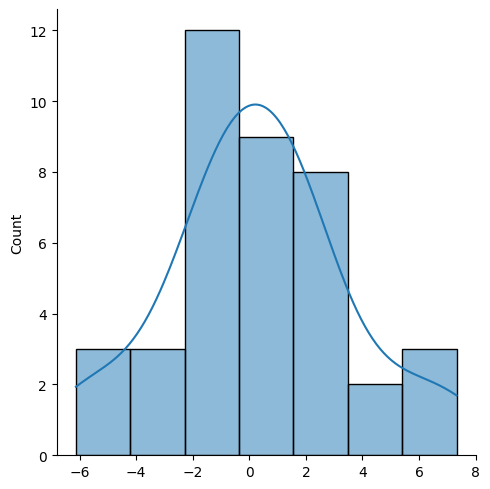

In [60]:
y_test_pred = lr.predict(X_test_sm)
res = y_test - y_test_pred
sns.displot(res, kde=True)

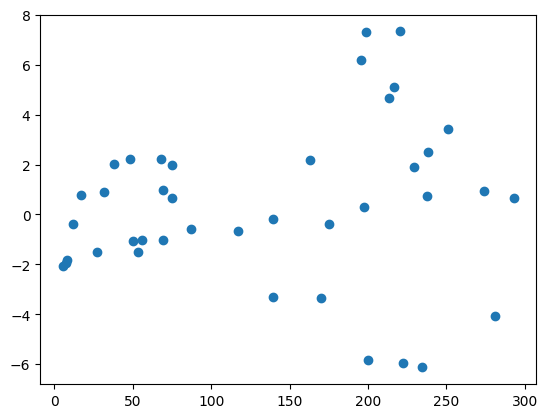

In [64]:
plt.scatter(X_test, res)

Equation

y = 7.119638 + 0.046530*x

C:\Users\gyana\AppData\Local\Temp\ipykernel_14188\2324197619.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(X_test, lr.params[0] + lr.params[1] * X_test, 'r')


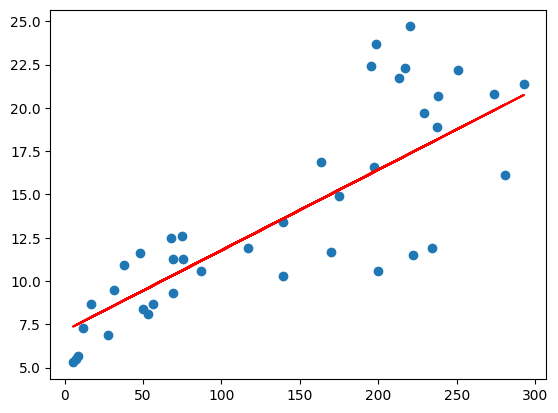

In [73]:
plt.scatter(X_test, y_test)
plt.plot(X_test, lr.params[0] + lr.params[1] * X_test, 'r')

Regression line visually confirms the linear relationship captured by the model.

In [68]:
from sklearn.metrics import mean_squared_error, r2_score

In [70]:
MSE = np.sqrt(mean_squared_error(y_test, y_test_pred))
MSE

np.float64(3.194472431998899)

Model performance evaluated using R² and RMSE.

Overall, the SLR model performs reasonably well and satisfies key linear regression assumptions.